##  Root Cause & Statistical Analysis 

## Day 4
Task 4

#### Cross-tab analysis 

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, f_oneway

In [3]:
df = pd.read_csv(r"C:\Users\Priti\Desktop\defect_data_cleaned.csv")   
df.head()

,defect_id,product_id,defect_type,defect_date,defect_location,severity,inspection_method,repair_cost,month,week,day_of_week
0,1,15,structural,06-06-2024,Component,Minor,Visual Inspection,245.47,6,23,Thursday
1,2,6,functional,26-04-2024,Component,Minor,Visual Inspection,26.87,4,17,Friday
2,3,84,structural,15-02-2024,Internal,Minor,Automated Testing,835.81,2,7,Thursday
3,4,10,functional,28-03-2024,Internal,Critical,Automated Testing,444.47,3,13,Thursday
4,5,14,cosmetic,26-04-2024,Component,Minor,Manual Testing,823.64,4,17,Friday


## Cross-tab analysis

####  Product( Machine) × Defect Type

In [9]:
machine_defect = pd.crosstab(df['product_id'], df['defect_type']) 
machine_defect

defect_type,cosmetic,functional,structural
product_id,,,
1,5,3,4
2,2,4,1
3,0,3,5
4,7,5,4
5,4,4,5
...,...,...,...
96,6,5,2
97,9,5,5
98,4,4,0


#### Shift(day_of_week)× Severity 

In [10]:
shift_severity = pd.crosstab(df['day_of_week'], df['severity'])
shift_severity 

severity,Critical,Minor,Moderate
day_of_week,,,
Friday,65,59,44
Monday,39,52,34
Saturday,43,53,62
Sunday,42,59,53
Thursday,51,41,34
Tuesday,56,51,42
Wednesday,37,43,40


####  Location (line proxy) × Defect Count

In [11]:
location_defect = df['defect_location'].value_counts()
location_defect

defect_location
Surface      353
Component    326
Internal     321
Name: count, dtype: int64

##  Statistical Tests

#### Chi-square test: defect_type vs severity

In [36]:
chi_table = pd.crosstab(df['defect_type'], df['severity'])
chi2, p, dof, expected = chi2_contingency(chi_table)
chi_table
print(f"\nChi-square Test (Defect Type vs Severity): chi2={chi2:.2f}, p-value={p:.4f}")


Chi-square Test (Defect Type vs Severity): chi2=3.57, p-value=0.4669


#### ANOVA: defect counts across shifts (day_of_week)

In [21]:
anova_data = [df[df['day_of_week']==day]['defect_id'].count() for day in df['day_of_week'].unique()]
anova_data 
f_stat, p_val = f_oneway(*[df[df['day_of_week']==day]['repair_cost'] for day in df['day_of_week'].unique()])
f_stat, p_val 
print(f"\nANOVA (Repair Cost across Shifts): F={f_stat:.2f}, p-value={p_val:.4f}")


ANOVA (Repair Cost across Shifts): F=1.61, p-value=0.1404


 #### Correlation analysis (numeric features)

In [26]:
numeric_corr = df[['repair_cost','month','week']].corr()
numeric_corr
print("\nCorrelation Matrix:\n", numeric_corr)


Correlation Matrix:
              repair_cost     month      week
repair_cost     1.000000 -0.010420 -0.008499
month          -0.010420  1.000000  0.985601
week           -0.008499  0.985601  1.000000


## Identify High-Risk Areas

#### High-risk machines (products with most defects)

In [28]:
high_risk_machines = df['product_id'].value_counts().head(5)
high_risk_machines
print("\nHigh-Risk Machines (Top 5 by defect count):\n", high_risk_machines)


High-Risk Machines (Top 5 by defect count):
 product_id
81    20
63    20
97    19
56    18
10    16
Name: count, dtype: int64


#### High-risk time periods (weeks with spikes)

In [29]:
weekly_trend = df.groupby('week').size()
spike_weeks = weekly_trend[weekly_trend > weekly_trend.quantile(0.75)]
print("\nHigh-Risk Weeks (spikes):\n", spike_weeks)


High-Risk Weeks (spikes):
 week
1     48
2     48
4     42
7     47
9     44
20    42
25    43
dtype: int64


####  Repeat defect patterns (defect_type × severity)

In [30]:
repeat_patterns = pd.crosstab(df['defect_type'], df['severity'])
print("\nRepeat Defect Patterns:\n", repeat_patterns)


Repeat Defect Patterns:
 severity     Critical  Minor  Moderate
defect_type                           
cosmetic          107    106        96
functional        114    113       112
structural        112    139       101


##  Visualization Examples

####  Heatmap: Machine × Defect Type

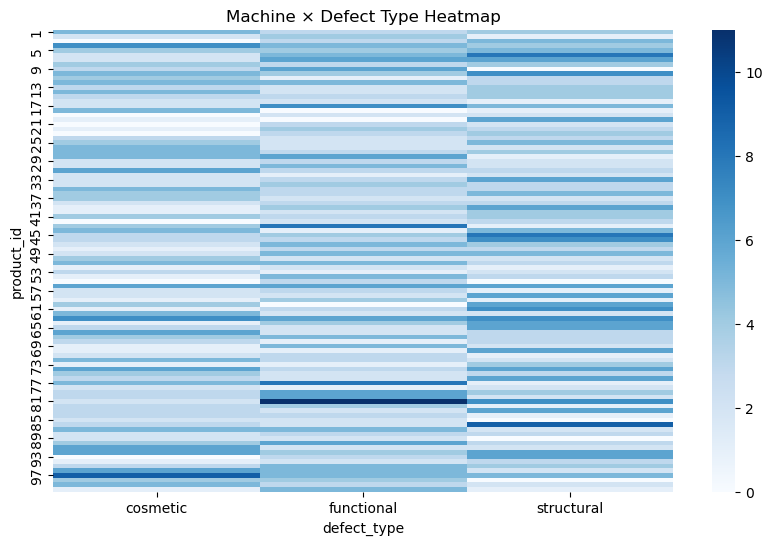

In [32]:
plt.figure(figsize=(10,6))
sns.heatmap(ct_machine_defect, cmap="Blues", annot=False)
plt.title("Machine × Defect Type Heatmap")
plt.show()

####  Heatmap: Shift × Severity

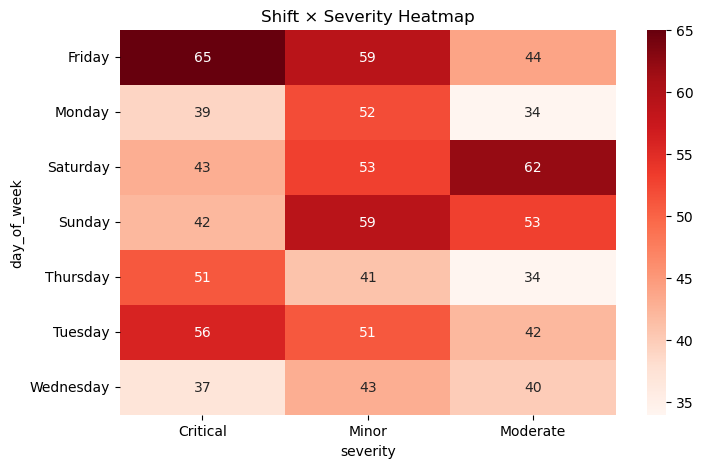

In [35]:
plt.figure(figsize=(8,5))
sns.heatmap(shift_severity, cmap="Reds", annot=True)
plt.title("Shift × Severity Heatmap")
plt.show()